In [1]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

In [13]:
import matplotlib.pyplot as plt

In [72]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
%pip install catboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.9/101.7 MB 17.4 MB/s eta 0:00:06
   -- ------------------------------------- 7.6/101.7 MB 20.2 MB/s eta 0:00:05
   ---- ----------------------------------- 12.6/101.7 MB 21.4 MB/s eta 0:00:05
   ------- -------------------------------- 17.8/101.7 MB 22.2 MB/s eta 0:00:04
   --------- ------------------------------ 23.9/101.7 MB 23.2 MB/s eta 0:00:04
   ----------- ---------------------------- 29.9/101.7 MB 24.1 MB/s eta 0:00:03
   -------------- ------------------------- 35.9/101.7 MB 24.6 MB/s eta 0:00:03
   ---------------- ----------------------- 41.4/101.7 MB 24.8 MB/s eta 0:00:03
   ------------------ --------------------- 47.4/101.7 MB 25.2 MB/s eta 0:00:03
   -------------------- ------------------- 53.0/101.7 MB 25.3 MB/s eta 0:00:02
   ---------------------- ----------------- 58.5/101.7 MB 25.4 MB/s eta 0:00:02
   ------------------------- -------------- 64.2/10

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:
%pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------------------------------------ --- 1.3/1.5 MB 9.9 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 8.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# =========================
# 1. Load Data
# =========================
train = pd.read_csv("midterm_train.csv")
test = pd.read_csv("midterm_test.csv")
dictionary = pd.read_csv("midterm_data_dictionary.csv")

print(train.shape)
print(test.shape)
train.head()

(32950, 23)
(8238, 22)


,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,...,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,...,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,...,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,...,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,...,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,...,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1


# 2. Basic EDA

#Data Overview

In [5]:
train.shape
train.head()
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         32950 non-null  int64  
 1   customer_age               32950 non-null  int64  
 2   occupation_type            32950 non-null  object 
 3   relationship_status        32950 non-null  object 
 4   education_background       32950 non-null  object 
 5   has_credit_issue           32950 non-null  object 
 6   mortgage_status            32950 non-null  object 
 7   personal_loan_status       32950 non-null  object 
 8   last_contact_month         32950 non-null  object 
 9   day_of_week                32950 non-null  object 
 10  contact_time_minutes       32950 non-null  int64  
 11  contact_attempt_count      32950 non-null  int64  
 12  days_since_prior_contact   32950 non-null  int64  
 13  prior_contact_count        32950 non-null  int

In [5]:
test.shape
test.head()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8238 entries, 0 to 8237
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         8238 non-null   int64  
 1   customer_age               8238 non-null   int64  
 2   occupation_type            8238 non-null   object 
 3   relationship_status        8238 non-null   object 
 4   education_background       8238 non-null   object 
 5   has_credit_issue           8238 non-null   object 
 6   mortgage_status            8238 non-null   object 
 7   personal_loan_status       8238 non-null   object 
 8   last_contact_month         8238 non-null   object 
 9   day_of_week                8238 non-null   object 
 10  contact_time_minutes       8238 non-null   int64  
 11  contact_attempt_count      8238 non-null   int64  
 12  days_since_prior_contact   8238 non-null   int64  
 13  prior_contact_count        8238 non-null   int64

# Dataset Structure

The training dataset contains 32,950 observations and 23 variables, while the test dataset contains 8,238 observations and 22 variables. The only missing column in the test set is the target variable, `accepted_offer`.

The dataset includes:
- Numerical variables related to customer information and economic indicators
- Multiple categorical variables related to customer demographics and campaign history
- Binary indicator variables describing previous customer interactions

Several categorical variables require encoding prior to modeling. In addition, the `id` column does not contain predictive information and was removed before training.

# check for missing and duplicate values  

In [7]:
train.isnull().sum()

id                           0
customer_age                 0
occupation_type              0
relationship_status          0
education_background         0
has_credit_issue             0
mortgage_status              0
personal_loan_status         0
last_contact_month           0
day_of_week                  0
contact_time_minutes         0
contact_attempt_count        0
days_since_prior_contact     0
prior_contact_count          0
prior_outcome_status         0
economic_activity_change     0
consumer_price_index         0
consumer_confidence_index    0
reference_interest_rate      0
employment_level_index       0
accepted_offer               0
is_repeat_customer           0
recent_contact_flag          0
dtype: int64

In [8]:
test.isnull().sum()

id                           0
customer_age                 0
occupation_type              0
relationship_status          0
education_background         0
has_credit_issue             0
mortgage_status              0
personal_loan_status         0
last_contact_month           0
day_of_week                  0
contact_time_minutes         0
contact_attempt_count        0
days_since_prior_contact     0
prior_contact_count          0
prior_outcome_status         0
economic_activity_change     0
consumer_price_index         0
consumer_confidence_index    0
reference_interest_rate      0
employment_level_index       0
is_repeat_customer           0
recent_contact_flag          0
dtype: int64

In [9]:
train.duplicated().sum()

np.int64(0)

In [10]:
test.duplicated().sum()

np.int64(0)

No missing values or duplicate observations were found in either the training or test datasets.

This simplifies preprocessing and removes the need for imputation strategies that could introduce additional uncertainty into the modeling process.

# Categorical Variable Exploration (train data and test data)

In [6]:
train.describe(include=["object"])

,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,prior_outcome_status
count,32950,32950,32950,32950,32950,32950,32950,32950,32950
unique,12,4,8,3,3,3,10,5,3
top,admin.,married,university.degree,no,yes,no,may,thu,nonexistent
freq,8336,19889,9772,26089,17291,27168,10980,6893,28452


In [22]:
test.describe(include=["object"])

,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,prior_outcome_status
count,8238,8238,8238,8238,8238,8238,8238,8238,8238
unique,12,4,8,2,3,3,10,5,3
top,admin.,married,university.degree,no,yes,no,may,thu,nonexistent
freq,2086,5039,2396,6499,4285,6782,2789,1730,7111


In [49]:
cat_cols = train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(cat_cols)

['occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'last_contact_month', 'day_of_week', 'prior_outcome_status']


In [14]:
for col in cat_cols:
    print(f"\n=== {col} ===")

    print("Train:")
    print(train[col].value_counts(normalize=True).head(10))

    print("\nTest:")
    print(test[col].value_counts(normalize=True).head(10))


=== occupation_type ===
Train:
occupation_type
admin.           0.252989
blue-collar      0.224431
technician       0.163399
services         0.096571
management       0.071320
retired          0.041760
entrepreneur     0.036146
self-employed    0.034385
housemaid        0.025554
unemployed       0.024036
Name: proportion, dtype: float64

Test:
occupation_type
admin.           0.253217
blue-collar      0.225662
technician       0.164967
services         0.095533
management       0.069677
retired          0.041758
self-employed    0.034960
entrepreneur     0.032168
unemployed       0.026948
housemaid        0.026463
Name: proportion, dtype: float64

=== relationship_status ===
Train:
relationship_status
married     0.603612
single      0.282822
divorced    0.111502
unknown     0.002064
Name: proportion, dtype: float64

Test:
relationship_status
married     0.611678
single      0.273003
divorced    0.113863
unknown     0.001457
Name: proportion, dtype: float64

=== education_background 

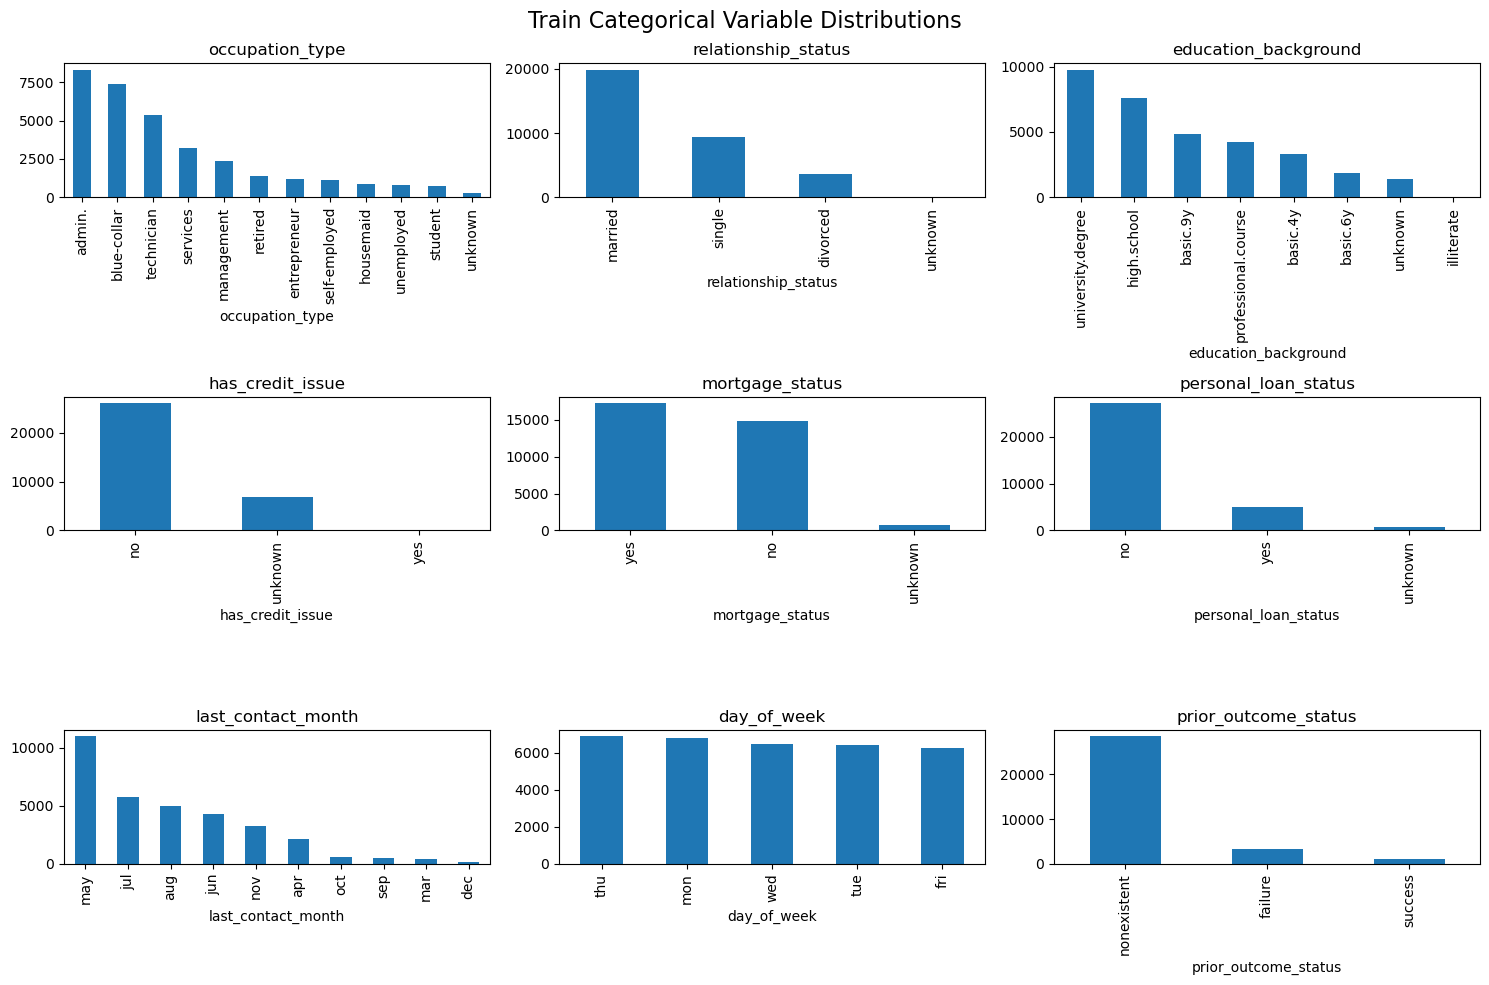

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15,10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    train[col].value_counts().plot(
        kind="bar",
        ax=axes[i],
        title=col
    )

plt.suptitle(
    "Train Categorical Variable Distributions",
    fontsize=16
)

plt.tight_layout()
plt.show()

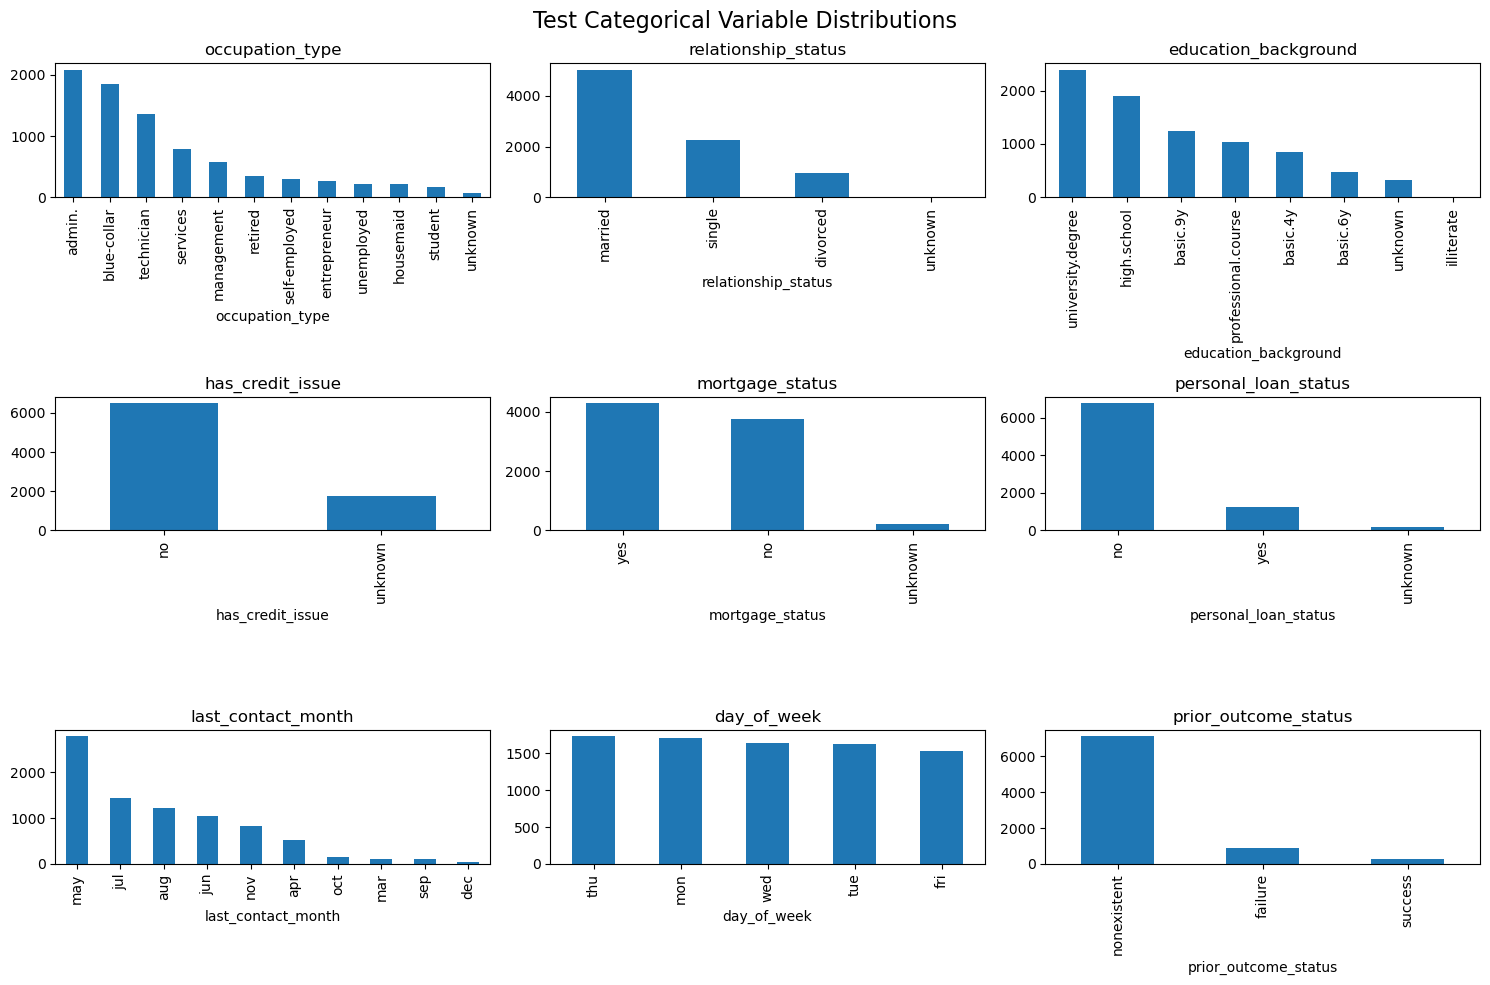

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(15,10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    test[col].value_counts().plot(
        kind="bar",
        ax=axes[i],
        title=col
    )

plt.suptitle(
    "Test Categorical Variable Distributions",
    fontsize=16
)

plt.tight_layout()
plt.show()

The categorical distributions in the training and test datasets were generally similar. This suggests that there was limited categorical distribution shift between the two datasets.

Several categorical variables were imbalanced. For example, `prior_outcome_status` was mostly `nonexistent`, and `has_credit_issue` was mostly `no`. Some variables also contained low-frequency categories such as `unknown` or `illiterate`.

Because these categories may still contain useful predictive information, they were retained rather than removed. These observations motivated the use of one-hot encoding and later feature engineering to better capture categorical patterns.

# Numerical Variable Exploration (train data and test data)

In [16]:
train.describe()

,id,customer_age,contact_time_minutes,contact_attempt_count,days_since_prior_contact,prior_contact_count,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
count,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000
mean,20612.919423,40.016813,257.355387,2.556601,961.748892,0.173445,0.077132,93.574951,-40.508273,3.614729,5166.787681,0.112747,0.136510,0.037511
std,11872.660725,10.421766,256.687433,2.751165,188.697125,0.496422,1.572468,0.579559,4.628221,1.737144,72.459588,0.316288,0.343334,0.190014
min,0.000000,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,0.000000,0.000000
25%,10373.250000,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000,0.000000,0.000000
50%,20610.500000,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000,0.000000,0.000000
75%,30858.750000,47.000000,318.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000,0.000000,0.000000
max,41187.000000,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000,1.000000,1.000000


In [27]:
test.describe()

,id,customer_age,contact_time_minutes,contact_attempt_count,days_since_prior_contact,prior_contact_count,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,is_repeat_customer,recent_contact_flag
count,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000
mean,20515.827021,40.053047,262.003277,2.611556,965.381525,0.171037,0.100898,93.578518,-40.479910,3.647536,5168.028769,0.136805,0.033867
std,11959.986153,10.419767,269.380643,2.843901,179.570652,0.488798,1.564865,0.575983,4.628316,1.723473,71.409010,0.343662,0.180899
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,0.000000
25%,9994.750000,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.354000,5099.100000,0.000000,0.000000
50%,20530.000000,38.000000,179.000000,2.000000,999.000000,0.000000,1.100000,93.798000,-41.800000,4.857000,5191.000000,0.000000,0.000000
75%,31024.500000,47.000000,324.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000,0.000000
max,41161.000000,95.000000,4199.000000,40.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000,1.000000


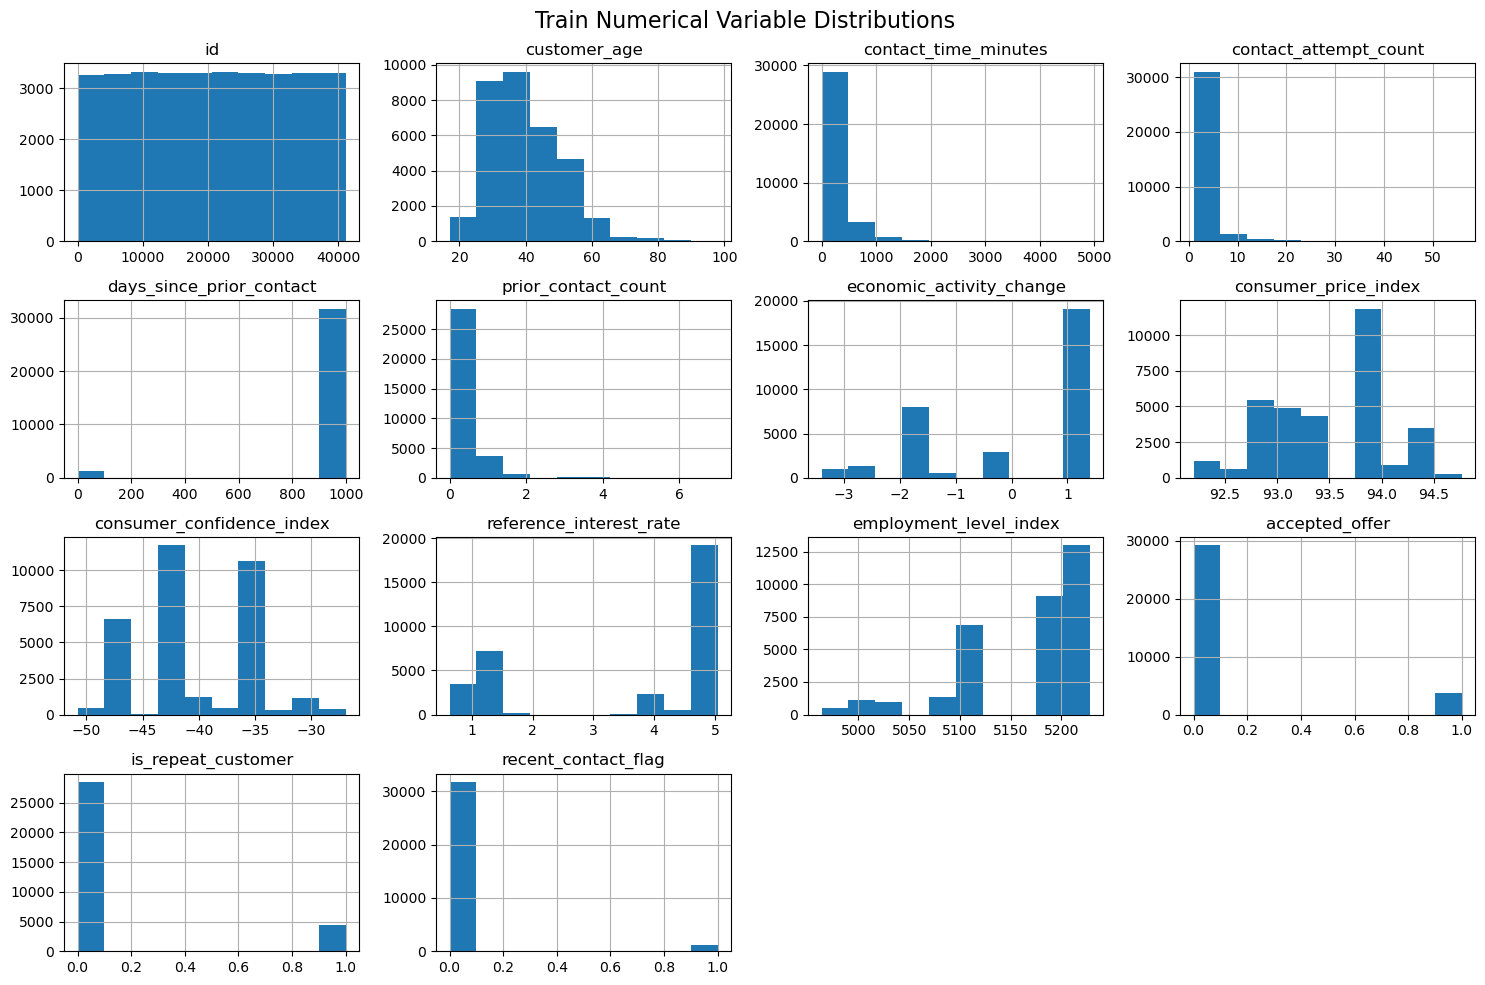

In [28]:
import matplotlib.pyplot as plt

train_num = train.select_dtypes(include=["int64", "float64"])

train_num.hist(figsize=(15,10))

plt.suptitle("Train Numerical Variable Distributions", fontsize=16)

plt.tight_layout()
plt.show()

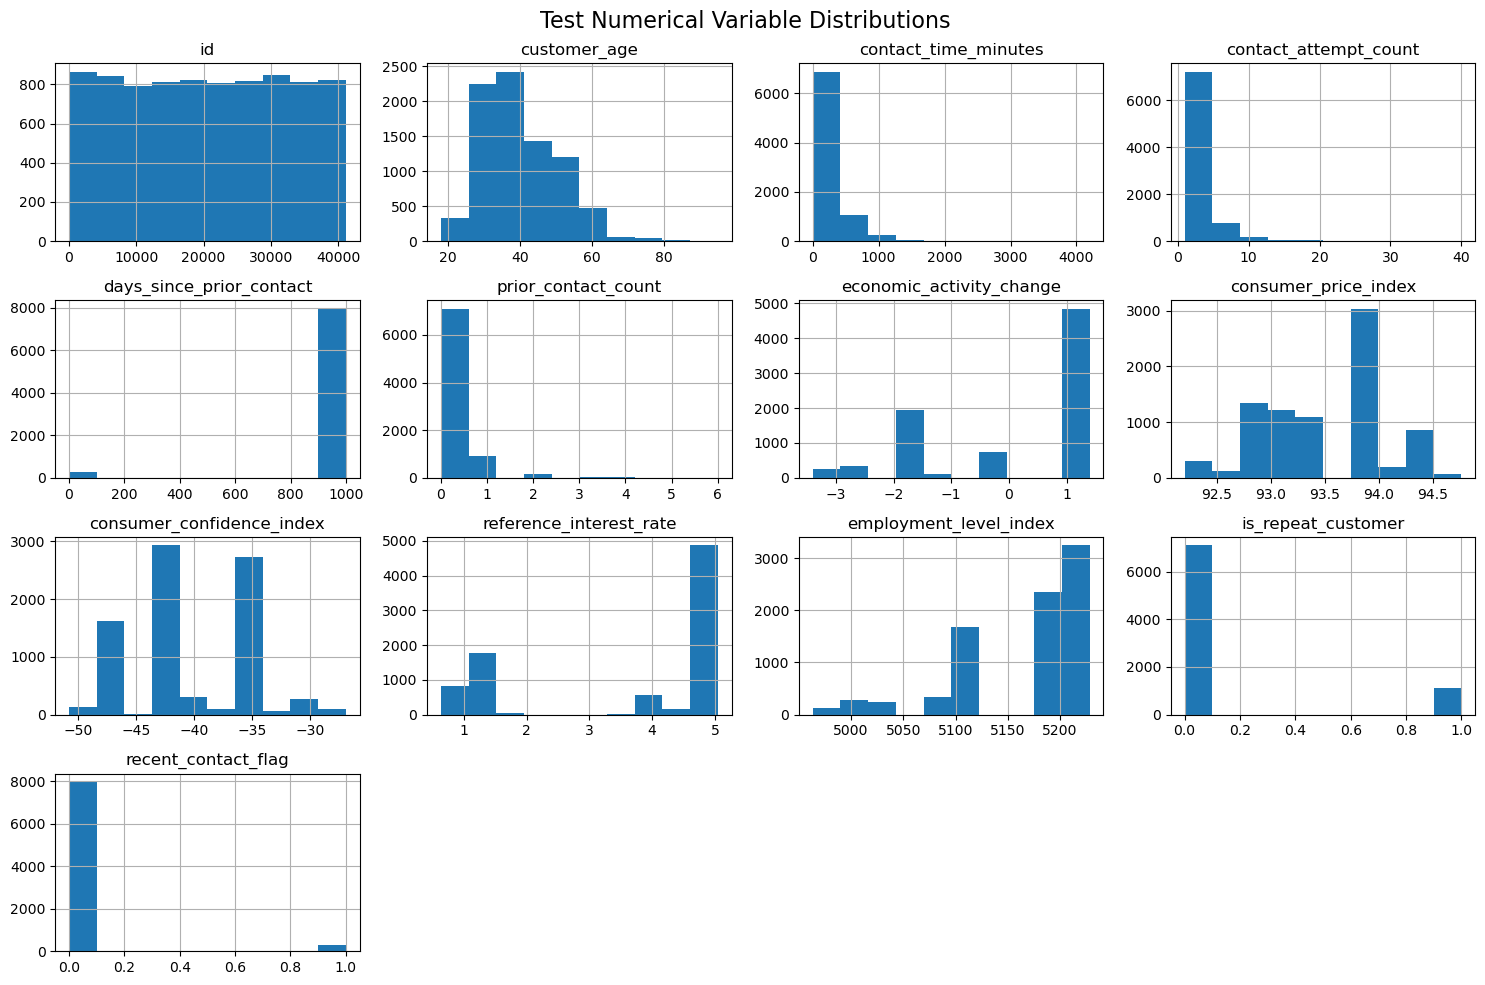

In [29]:
test_num = test.select_dtypes(include=["int64", "float64"])

test_num.hist(figsize=(15,10))

plt.suptitle("Test Numerical Variable Distributions", fontsize=16)

plt.tight_layout()
plt.show()

The numerical variable distributions between the training and test datasets appeared generally consistent, suggesting limited numerical distribution shift.

Several variables, including `contact_time_minutes`, `contact_attempt_count`, and `prior_contact_count`, showed heavily right-skewed distributions and contained potential outliers. These variables represent customer interaction behavior and may contain important non-linear relationships.

In contrast, macroeconomic variables such as `reference_interest_rate`, `employment_level_index`, and `consumer_confidence_index` showed more structured distributions, suggesting that economic conditions may influence customer responses in meaningful ways.

These observations motivated later feature engineering steps involving interaction terms, ratio-based features, and tree-based ensemble models capable of capturing non-linear patterns.

# Target Distribution

In [9]:
target = "accepted_offer"

train[target].value_counts()
train[target].value_counts(normalize=True)

accepted_offer
0    0.887253
1    0.112747
Name: proportion, dtype: float64

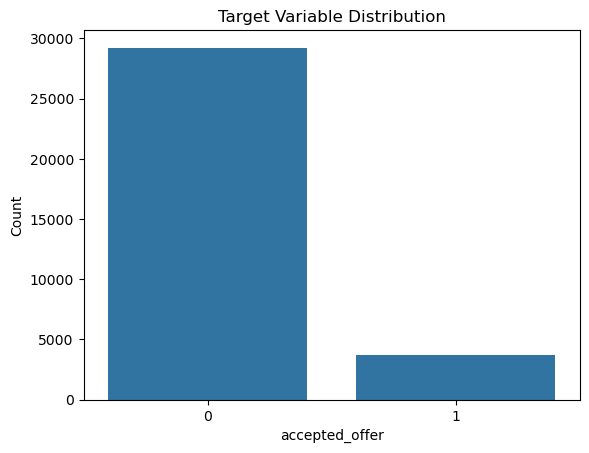

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x=train["accepted_offer"]
)

plt.title("Target Variable Distribution")
plt.xlabel("accepted_offer")
plt.ylabel("Count")

plt.show()

The target variable is highly imbalanced, with approximately 88.7% of observations belonging to class 0 and only 11.3% belonging to class 1. This indicates that the dataset is heavily skewed toward the negative class.

Because of this imbalance, overall accuracy would not be an appropriate evaluation metric. Therefore, F1 score was used as the primary metric to better evaluate minority class performance. In addition, Stratified 5-Fold Cross-Validation was applied to preserve class proportions during model evaluation.

# Variables vs Target relationship 

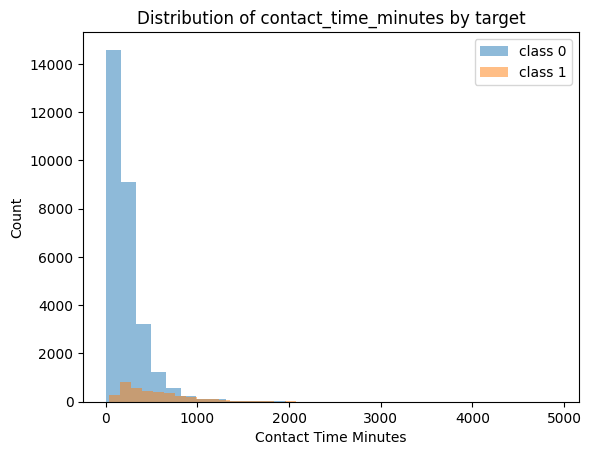

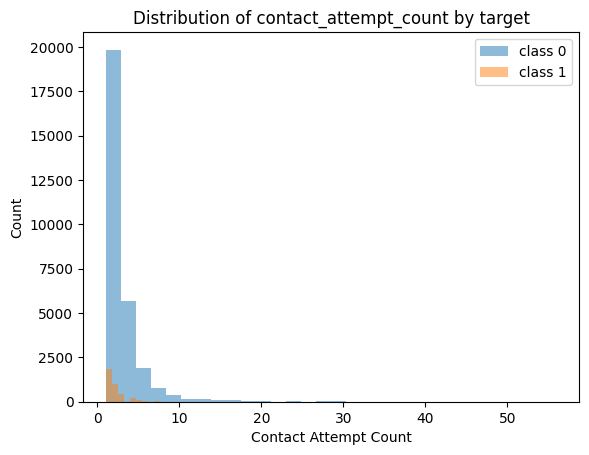

In [93]:
cols = ['contact_time_minutes', 'contact_attempt_count']

for col in cols:
    plt.figure()
    
    for label in train['accepted_offer'].unique():
        subset = train[train['accepted_offer'] == label]
        plt.hist(subset[col], bins=30, alpha=0.5, label=f"class {label}")
    
    plt.title(f"Distribution of {col} by target")
    
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Count")
    
    plt.legend()
    plt.show()

Several important patterns were observed from the variable distributions.

The feature `contact_time_minutes` was highly right-skewed, with most customer interactions being relatively short and a small number of extremely long calls. Customers who accepted the offer generally showed longer contact durations, suggesting that engagement intensity may contain predictive information.

Similarly, `contact_attempt_count` was also strongly right-skewed, with most customers contacted only a few times. The distributions differed across target classes, indicating potential non-linear relationships between customer contact behavior and offer acceptance.

In addition, `days_since_prior_contact` showed a large concentration near the value `999`, likely representing customers without recent prior contact information. This suggested that the variable required careful interpretation during feature engineering.

Overall, these observations influenced later modeling decisions. The skewed distributions and potential non-linear relationships motivated the use of feature engineering and tree-based ensemble models, while the class imbalance supported the use of F1 score and Stratified Cross-Validation for evaluation.

# Variable correlation with the target variable

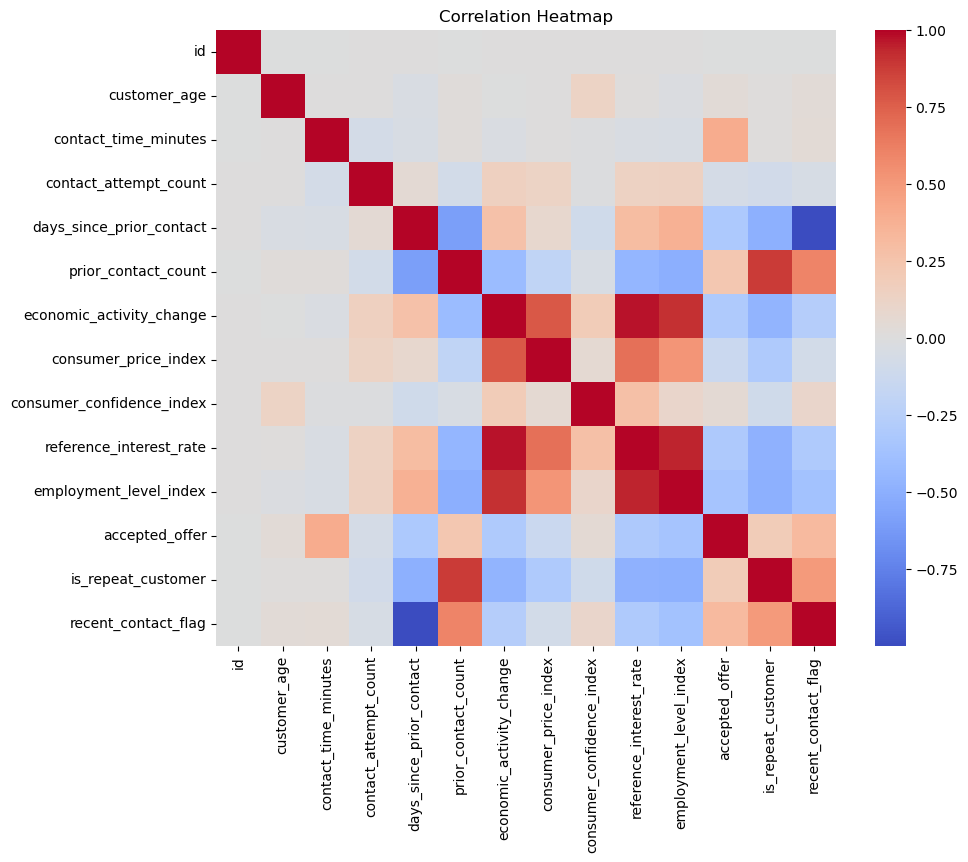

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = train.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap revealed several moderate to strong relationships among the numerical variables.

Macroeconomic variables such as `reference_interest_rate`, `employment_level_index`, and `economic_activity_change` showed strong positive correlations, indicating that these features may capture overlapping economic conditions.

In addition, customer contact-related variables, including `prior_contact_count`, `is_repeat_customer`, and `recent_contact_flag`, also demonstrated noticeable relationships.

Most variables did not exhibit severe multicollinearity, suggesting that retaining multiple features would still provide useful information for tree-based ensemble models. However, these relationships motivated additional feature engineering and feature importance analysis later in the workflow.

# Data Preparation

In [7]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd

target = "accepted_offer"
id_col = "id"

# Separate features, target, and test ids
X = train.drop(columns=[target, id_col])
y = train[target]

test_ids = test[id_col]
X_test = test.drop(columns=[id_col])

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=False)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)

# Align train and test columns after encoding
X_encoded, X_test_encoded = X_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

# Make sure test column order matches train column order
X_test_encoded = X_test_encoded[X_encoded.columns]

# Stratified CV due to target imbalance
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Train shape after encoding:", X_encoded.shape)
print("Test shape after encoding:", X_test_encoded.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

Categorical columns: ['occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'last_contact_month', 'day_of_week', 'prior_outcome_status']
Numerical columns: ['customer_age', 'contact_time_minutes', 'contact_attempt_count', 'days_since_prior_contact', 'prior_contact_count', 'economic_activity_change', 'consumer_price_index', 'consumer_confidence_index', 'reference_interest_rate', 'employment_level_index', 'is_repeat_customer', 'recent_contact_flag']
Train shape after encoding: (32950, 63)
Test shape after encoding: (8238, 63)
Target distribution:
accepted_offer
0    0.887253
1    0.112747
Name: proportion, dtype: float64


Based on the EDA results, the dataset was relatively clean with no missing values, so no imputation was required. Since the data included multiple categorical variables, one-hot encoding was applied to convert categorical features into numerical representations suitable for machine learning models.

Although one-hot encoding increased feature dimensionality, tree-based ensemble methods are generally robust to high-dimensional feature spaces. In addition, due to the imbalance in the target variable, Stratified Cross-Validation was used to preserve class proportions during model evaluation and improve reliability. Finally, the `id` column was removed because it does not contain meaningful predictive information.

# Baseline Modeling

In [46]:
%pip install catboost

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   - -------------------------------------- 5.0/100.2 MB 26.7 MB/s eta 0:00:04
   ---- ----------------------------------- 10.7/100.2 MB 26.4 MB/s eta 0:00:04
   ------ --------------------------------- 16.3/100.2 MB 26.3 MB/s eta 0:00:04
   -------- ------------------------------- 22.0/100.2 MB 26.4 MB/s eta 0:00:03
   ----------- ---------------------------- 27.8/100.2 MB 26.4 MB/s eta 0:00:03
   ------------- -------------------------- 33.8/100.2 MB 26.6 MB/s eta 0:00:03
   --------------- ------------------------ 39.6/100.2 MB 26.6 MB/s eta 0:00:03
   ------------------ --------------------- 45.4/100.2 MB 26.7 MB/s eta 0:00:03
   -------------------- ------------------- 51.4/100.2 MB 26.8 MB/s eta 0:00:02
   ---------------------- ----------------- 57.1/100.2 MB 26.8 MB/s eta 0:00:02
   ------------------------- -------------- 62.7/100.2 MB 26.7 MB/s

In [47]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import pandas as pd

# Define baseline models
baseline_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        random_state=42,
        verbose=0
    )
}

# Evaluate models using Stratified 5-Fold Cross-Validation
baseline_results = []

for name, model in baseline_models.items():

    scores = cross_validate(
        model,
        X_encoded,
        y,
        cv=cv,
        scoring=["accuracy", "f1"],
        n_jobs=-1
    )

    baseline_results.append({
        "Model": name,
        "Mean CV Accuracy": scores["test_accuracy"].mean(),
        "Mean CV F1": scores["test_f1"].mean(),
        "Std CV F1": scores["test_f1"].std()
    })

# Convert to dataframe
baseline_results = pd.DataFrame(baseline_results)

# Sort by F1
baseline_results = baseline_results.sort_values(
    "Mean CV F1",
    ascending=False
)

baseline_results

,Model,Mean CV Accuracy,Mean CV F1,Std CV F1
3,LightGBM,0.881760,0.630521,0.010322
4,CatBoost,0.916449,0.590105,0.012713
2,XGBoost,0.915539,0.586165,0.017396
0,Logistic Regression,0.857845,0.583827,0.008108
1,Random Forest,0.909651,0.496774,0.017722


Five baseline models were evaluated using Stratified 5-Fold Cross-Validation: Logistic Regression, Random Forest, XGBoost, LightGBM, and CatBoost.

Both Accuracy and F1 score were calculated for model comparison. However, because the target variable was imbalanced, F1 score was treated as the primary evaluation metric.

Among the baseline models, LightGBM achieved the strongest overall performance, obtaining the highest Mean CV F1 score.

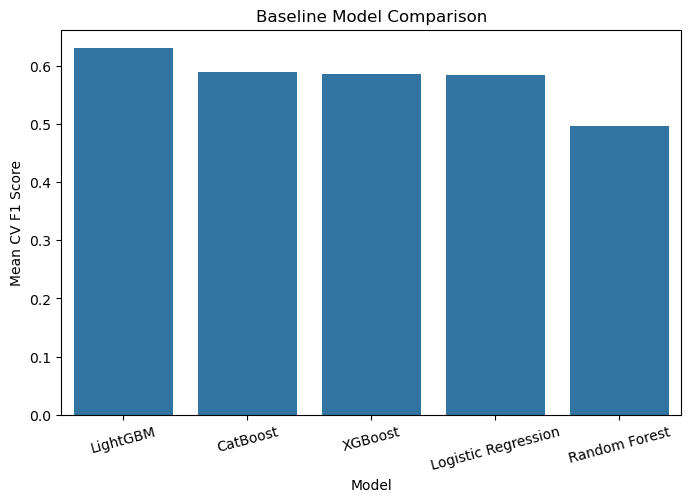

In [48]:
# Visualization of baseline model performance

plt.figure(figsize=(8,5))

sns.barplot(
    data=baseline_results,
    x="Model",
    y="Mean CV F1"
)

plt.title("Baseline Model Comparison")
plt.ylabel("Mean CV F1 Score")
plt.xlabel("Model")

plt.xticks(rotation=15)

plt.show()

Among the baseline models, LightGBM achieved the best overall performance, followed by Catboost and XGBoost. Random Forest performed substantially worse compared to the boosting-based methods.

These results suggest that boosting algorithms are better able to capture the non-linear relationships and interaction effects present in the dataset. In contrast, the relatively weaker performance of Logistic Regression indicates that the data may not be well represented by simple linear decision boundaries.

#Feature Engineering

In [26]:
# Create copies
X_fe = X.copy()
X_test_fe = X_test.copy()

# Interaction feature
X_fe["time_x_attempt"] = (
    X_fe["contact_time_minutes"] * X_fe["contact_attempt_count"]
)

X_test_fe["time_x_attempt"] = (
    X_test_fe["contact_time_minutes"] * X_test_fe["contact_attempt_count"]
)

# Ratio feature
X_fe["time_per_attempt"] = (
    X_fe["contact_time_minutes"] / (X_fe["contact_attempt_count"] + 1)
)

X_test_fe["time_per_attempt"] = (
    X_test_fe["contact_time_minutes"] / (X_test_fe["contact_attempt_count"] + 1)
)

# Special value handling (999)
X_fe["has_prior_contact"] = (
    X_fe["days_since_prior_contact"] != 999
).astype(int)

X_test_fe["has_prior_contact"] = (
    X_test_fe["days_since_prior_contact"] != 999
).astype(int)

In [27]:
cat_cols_fe = X_fe.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

X_fe_encoded = pd.get_dummies(
    X_fe,
    columns=cat_cols_fe,
    drop_first=False
)

X_test_fe_encoded = pd.get_dummies(
    X_test_fe,
    columns=cat_cols_fe,
    drop_first=False
)

# Align train and test columns
X_fe_encoded, X_test_fe_encoded = X_fe_encoded.align(
    X_test_fe_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print("Train shape after feature engineering:", X_fe_encoded.shape)
print("Test shape after feature engineering:", X_test_fe_encoded.shape)

Train shape after feature engineering: (32950, 66)
Test shape after feature engineering: (8238, 66)


In [49]:
# Evaluate the same baseline models after feature engineering
fe_results = []

for name, model in baseline_models.items():
    scores = cross_validate(
        model,
        X_fe_encoded,
        y,
        cv=cv,
        scoring=["accuracy", "f1"],
        n_jobs=-1
    )
    
    fe_results.append({
        "Model": name,
        "Mean CV Accuracy": scores["test_accuracy"].mean(),
        "Mean CV F1": scores["test_f1"].mean(),
        "Std CV F1": scores["test_f1"].std()
    })

fe_results = pd.DataFrame(fe_results)
fe_results = fe_results.sort_values("Mean CV F1", ascending=False)

fe_results

,Model,Mean CV Accuracy,Mean CV F1,Std CV F1
3,LightGBM,0.884067,0.634447,0.009505
2,XGBoost,0.916055,0.590213,0.018195
4,CatBoost,0.915539,0.584569,0.010067
0,Logistic Regression,0.856449,0.581866,0.010352
1,Random Forest,0.913596,0.558289,0.014683


In [50]:
comparison = baseline_results[["Model", "Mean CV F1"]].rename(
    columns={"Mean CV F1": "Baseline Mean CV F1"}
).merge(
    fe_results[["Model", "Mean CV F1"]].rename(
        columns={"Mean CV F1": "Feature Engineering Mean CV F1"}
    ),
    on="Model"
)

comparison["CV F1 Improvement"] = (
    comparison["Feature Engineering Mean CV F1"]
    - comparison["Baseline Mean CV F1"]
)

comparison = comparison.sort_values(
    "Feature Engineering Mean CV F1",
    ascending=False
)

comparison

,Model,Baseline Mean CV F1,Feature Engineering Mean CV F1,CV F1 Improvement
0,LightGBM,0.630521,0.634447,0.003926
2,XGBoost,0.586165,0.590213,0.004049
1,CatBoost,0.590105,0.584569,-0.005536
3,Logistic Regression,0.583827,0.581866,-0.001961
4,Random Forest,0.496774,0.558289,0.061515


Feature engineering improved the performance of several tree-based models, particularly Random Forest, XGBoost, and LightGBM.

Random Forest showed the largest improvement after feature engineering, suggesting that interaction-based behavioral features provided additional predictive information that was not fully captured by the original variables alone.

LightGBM remained the best-performing model overall, achieving the highest Mean CV F1 score after feature engineering. In contrast, CatBoost and Logistic Regression showed slight performance decreases, indicating that different models responded differently to the engineered feature set.

#Feature Selection

In [32]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

In [33]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_validate
import pandas as pd

# Fit XGBoost on feature-engineered data
xgb.fit(X_fe_encoded, y)

# Permutation importance
perm = permutation_importance(
    xgb,
    X_fe_encoded,
    y,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring="f1"
)

# Convert to dataframe
feature_importance = pd.DataFrame({
    "Feature": X_fe_encoded.columns,
    "Importance": perm.importances_mean
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

# Display top features
top_features = feature_importance.head(20)

top_features

,Feature,Importance
1,contact_time_minutes,0.271437
9,employment_level_index,0.132061
13,time_per_attempt,0.117399
5,economic_activity_change,0.116990
8,reference_interest_rate,0.065880
12,time_x_attempt,0.046242
3,days_since_prior_contact,0.023869
7,consumer_confidence_index,0.023337
0,customer_age,0.017944
54,last_contact_month_may,0.012086


The feature importance analysis revealed that `contact_time_minutes` was the most influential predictor, followed by several macroeconomic indicators and engineered behavioral features.

Importantly, the engineered variables `time_per_attempt` and `time_x_attempt` ranked among the top predictors, confirming that the feature engineering process successfully captured additional customer engagement patterns.

These results were also consistent with the earlier EDA findings, where longer contact durations were associated with higher acceptance rates.

In [51]:
# Select top features
selected_features = top_features["Feature"].tolist()

X_top = X_fe_encoded[selected_features]
X_test_top = X_test_fe_encoded[selected_features]

# Evaluate models using selected features
fs_results = []

for name, model in baseline_models.items():

    scores = cross_validate(
        model,
        X_top,
        y,
        cv=cv,
        scoring=["accuracy", "f1"],
        n_jobs=-1
    )

    fs_results.append({
        "Model": name,
        "Mean CV Accuracy": scores["test_accuracy"].mean(),
        "Feature Selection Mean CV F1": scores["test_f1"].mean(),
        "Std CV F1": scores["test_f1"].std()
    })

# Convert to dataframe
fs_results = pd.DataFrame(fs_results)

# Sort by Feature Selection Mean CV F1
fs_results = fs_results.sort_values(
    "Feature Selection Mean CV F1",
    ascending=False
)

# Display results
fs_results

,Model,Mean CV Accuracy,Feature Selection Mean CV F1,Std CV F1
3,LightGBM,0.880334,0.627629,0.008280
2,XGBoost,0.916510,0.594451,0.013156
4,CatBoost,0.916358,0.589440,0.011454
0,Logistic Regression,0.855842,0.579455,0.010731
1,Random Forest,0.910895,0.557789,0.014201


In [52]:
# Compare Baseline, Feature Engineering, and Feature Selection results

overall_comparison = baseline_results[[
    "Model",
    "Mean CV F1"
]].rename(
    columns={"Mean CV F1": "Baseline Mean CV F1"}
).merge(
    fe_results[[
        "Model",
        "Mean CV F1"
    ]].rename(
        columns={"Mean CV F1": "Feature Engineering Mean CV F1"}
    ),
    on="Model"
).merge(
    fs_results[[
        "Model",
        "Feature Selection Mean CV F1"
    ]],
    on="Model"
)

# Improvement calculations
overall_comparison["FE Improvement"] = (
    overall_comparison["Feature Engineering Mean CV F1"]
    - overall_comparison["Baseline Mean CV F1"]
)

overall_comparison["FS Improvement"] = (
    overall_comparison["Feature Selection Mean CV F1"]
    - overall_comparison["Feature Engineering Mean CV F1"]
)

# Sort by best final performance
overall_comparison = overall_comparison.sort_values(
    "Feature Selection Mean CV F1",
    ascending=False
)

overall_comparison

,Model,Baseline Mean CV F1,Feature Engineering Mean CV F1,Feature Selection Mean CV F1,FE Improvement,FS Improvement
0,LightGBM,0.630521,0.634447,0.627629,0.003926,-0.006818
2,XGBoost,0.586165,0.590213,0.594451,0.004049,0.004238
1,CatBoost,0.590105,0.584569,0.589440,-0.005536,0.004871
3,Logistic Regression,0.583827,0.581866,0.579455,-0.001961,-0.002411
4,Random Forest,0.496774,0.558289,0.557789,0.061515,-0.000500


Feature selection was performed after feature engineering so that both original variables and engineered interaction features could be evaluated together during the selection process.

XGBoost and CatBoost both showed slight improvements after removing lower-importance variables, suggesting that reducing noisy features improved generalization performance. In contrast, LightGBM experienced a small decrease in performance, likely because gradient boosting models can naturally handle high-dimensional feature spaces effectively.

Random Forest benefited substantially from feature engineering, but feature selection provided little additional improvement. Overall, the feature selection process helped simplify the feature space while maintaining competitive predictive performance across most models.

# Hyperparameter Tuning

Hyperparameter tuning was performed on the strongest tree-based boosting models, including XGBoost, LightGBM, and CatBoost, using GridSearchCV with Stratified 5-Fold Cross-Validation.

F1 score was used as the primary tuning metric because the target variable was imbalanced.

The tuning process used different feature sets for different models based on earlier evaluation results. LightGBM performed better using the full feature-engineered dataset, while XGBoost and CatBoost slightly benefited from the reduced feature set after feature selection.

In [55]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

# LightGBM tuning
lgbm_model = LGBMClassifier(
    random_state=42,
    class_weight="balanced",
    verbose=-1
)

lgbm_param_grid = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 4, 6],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

lgbm_grid = GridSearchCV(
    estimator=lgbm_model,
    param_grid=lgbm_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Use feature-engineered dataset
lgbm_grid.fit(X_fe_encoded, y)

print("Best LightGBM parameters:", lgbm_grid.best_params_)
print("Best LightGBM Mean CV F1:", lgbm_grid.best_score_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best LightGBM parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': -1, 'n_estimators': 500, 'num_leaves': 63, 'subsample': 0.8}
Best LightGBM Mean CV F1: 0.6463599023290498


In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# XGBoost tuning
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_param_grid = {
    "n_estimators": [200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_top, y)

print("Best XGBoost parameters:", xgb_grid.best_params_)
print("Best XGBoost Mean CV F1:", xgb_grid.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best XGBoost parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
Best XGBoost Mean CV F1: 0.5990192842922247


In [ ]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    random_state=42,
    verbose=0
)

cat_param_grid = {
    "iterations": [200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "depth": [4, 6, 8]
}

cat_grid = GridSearchCV(
    estimator=cat_model,
    param_grid=cat_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

cat_grid.fit(X_top, y) # X_final = X_top

print("Best CatBoost parameters:", cat_grid.best_params_)
print("Best CatBoost Mean CV F1:", cat_grid.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best CatBoost parameters: {'depth': 6, 'iterations': 200, 'learning_rate': 0.05}
Best CatBoost Mean CV F1: 0.5923125369773549


In [57]:
tuning_results = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost", "CatBoost"],

    "Before Tuning Mean CV F1": [

        # LightGBM used Feature Engineering dataset
        fe_results.loc[
            fe_results["Model"] == "LightGBM",
            "Mean CV F1"
        ].values[0],

        # XGBoost used Feature Selection dataset
        fs_results.loc[
            fs_results["Model"] == "XGBoost",
            "Feature Selection Mean CV F1"
        ].values[0],

        # CatBoost used Feature Selection dataset
        fs_results.loc[
            fs_results["Model"] == "CatBoost",
            "Feature Selection Mean CV F1"
        ].values[0]
    ],

    "After Tuning Mean CV F1": [
        lgbm_grid.best_score_,
        xgb_grid.best_score_,
        cat_grid.best_score_
    ]
})

# Improvement
tuning_results["CV F1 Improvement"] = (
    tuning_results["After Tuning Mean CV F1"]
    - tuning_results["Before Tuning Mean CV F1"]
)

# Sort
tuning_results = tuning_results.sort_values(
    "After Tuning Mean CV F1",
    ascending=False
)

tuning_results

,Model,Before Tuning Mean CV F1,After Tuning Mean CV F1,CV F1 Improvement
0,LightGBM,0.634447,0.646360,0.011913
1,XGBoost,0.594451,0.599019,0.004568
2,CatBoost,0.589440,0.592313,0.002873


The tuning process used different feature sets for different models based on earlier evaluation results.

LightGBM achieved stronger performance using the full feature-engineered dataset, so hyperparameter tuning was performed directly on the feature-engineered features without feature selection.

In contrast, both XGBoost and CatBoost showed slight improvements after feature selection, suggesting that removing lower-importance variables improved generalization performance. Therefore, XGBoost and CatBoost tuning were performed using the selected top features.

Hyperparameter tuning further improved the performance of all boosting models, particularly LightGBM, which achieved the highest overall Mean CV F1 score among all evaluated models. These results suggest that tree-based boosting methods were highly effective for this classification task.

# Ensembling (Soft voting and weighted voting)


Ensemble methods were applied to determine whether combining multiple tuned boosting models could further improve predictive performance.

Probability blending was selected because the strongest individual models — LightGBM, XGBoost, and CatBoost — differed in their boosting strategies, tree construction methods, and handling of feature interactions. Combining these models allowed the ensemble to leverage complementary predictive patterns learned by each algorithm.

Soft probability blending combines predicted probabilities using equal model weights, while weighted probability blending assigns larger influence to stronger-performing models. Since LightGBM achieved the highest Mean CV F1 score during tuning, higher ensemble weights were assigned to LightGBM in the weighted blending approach.

In [58]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd
import numpy as np

# Best tuned models
final_lgbm = lgbm_grid.best_estimator_
final_xgb = xgb_grid.best_estimator_
final_cat = cat_grid.best_estimator_

# Out-of-fold predicted probabilities
lgbm_oof = cross_val_predict(
    final_lgbm,
    X_fe_encoded,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)

xgb_oof = cross_val_predict(
    final_xgb,
    X_top,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)

cat_oof = cross_val_predict(
    final_cat,
    X_top,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)

To build the ensemble models, out-of-fold (OOF) predicted probabilities were generated for each tuned boosting model using cross-validation.

OOF probabilities help simulate unseen validation predictions while reducing information leakage during blending. Different feature sets were used for different models based on earlier evaluation results: LightGBM used the full feature-engineered dataset, while XGBoost and CatBoost used the reduced feature-selected dataset.

In [ ]:
# Soft voting / equal-weight blending

In [59]:
# Equal-weight probability blending
soft_blended_probs = (
    lgbm_oof[:, 1] +
    xgb_oof[:, 1] +
    cat_oof[:, 1]
) / 3

soft_blended_preds = (soft_blended_probs >= 0.5).astype(int)

soft_f1 = f1_score(y, soft_blended_preds)
soft_acc = accuracy_score(y, soft_blended_preds)

print("Soft Blending Accuracy:", soft_acc)
print("Soft Blending F1:", soft_f1)

Soft Blending Accuracy: 0.9153262518968134
Soft Blending F1: 0.6491448692152918


Soft probability blending was first applied using equal model weights. The predicted probabilities from the tuned LightGBM, XGBoost, and CatBoost models were averaged to generate the final ensemble predictions.

This approach assumes that all models contribute equally to the final prediction and serves as a baseline ensemble strategy before applying weighted blending.

# Weighted blending

In [60]:
# Weighted probability blending
# Higher weight assigned to LightGBM because it had the strongest tuned CV performance
w_lgbm = 3
w_xgb = 2
w_cat = 1

weighted_blended_probs = (
    w_lgbm * lgbm_oof[:, 1] +
    w_xgb * xgb_oof[:, 1] +
    w_cat * cat_oof[:, 1]
) / (w_lgbm + w_xgb + w_cat)

weighted_blended_preds = (weighted_blended_probs >= 0.5).astype(int)

weighted_f1 = f1_score(y, weighted_blended_preds)
weighted_acc = accuracy_score(y, weighted_blended_preds)

print("Weighted Blending Accuracy:", weighted_acc)
print("Weighted Blending F1:", weighted_f1)

Weighted Blending Accuracy: 0.9104097116843702
Weighted Blending F1: 0.6557835820895522


Weighted probability blending was then applied by assigning larger ensemble weights to stronger-performing models.

Because LightGBM achieved the highest tuned Mean CV F1 score, it received the largest blending weight. XGBoost received the second-largest weight, while CatBoost received the smallest weight based on relative model performance.

The weighted blending approach aimed to improve ensemble performance by giving greater influence to the models with stronger validation results.

In [62]:
ensemble_results = pd.DataFrame({
    "Model": ["Soft Probability Blending", "Weighted Probability Blending"],
    "Mean CV Accuracy": [soft_acc, weighted_acc],
    "Mean CV F1": [soft_f1, weighted_f1]
})

ensemble_results = ensemble_results.sort_values(
    "Mean CV F1",
    ascending=False
)

ensemble_results

,Model,Mean CV Accuracy,Mean CV F1
1,Weighted Probability Blending,0.910410,0.655784
0,Soft Probability Blending,0.915326,0.649145


The ensemble results showed that combining tuned boosting models further improved predictive performance.

Weighted probability blending achieved the highest overall Mean CV F1 score, outperforming both the individual tuned models and the equal-weight soft blending approach. This suggests that assigning larger ensemble weights to stronger-performing models, particularly LightGBM, improved the overall predictive balance of the ensemble.

Overall, the ensemble models demonstrated that combining multiple boosting approaches could capture complementary predictive patterns more effectively than any single model alone.

# Results Summary

The following table summarizes the major modeling stages and final ensemble results. Models were evaluated using Stratified 5-Fold Cross-Validation with F1 score as the primary evaluation metric due to class imbalance.

In [65]:
results_summary = pd.DataFrame({

    "Model": [

        # Baseline models
        "Logistic Regression Baseline",
        "Random Forest Baseline",
        "XGBoost Baseline",
        "LightGBM Baseline",
        "CatBoost Baseline",

        # Feature Engineering
        "LightGBM + Feature Engineering",
        "XGBoost + Feature Engineering",
        "CatBoost + Feature Engineering",

        # Feature Selection
        "LightGBM + Feature Selection",
        "XGBoost + Feature Selection",
        "CatBoost + Feature Selection",

        # Tuned models
        "LightGBM Tuned",
        "XGBoost Tuned",
        "CatBoost Tuned",

        # Ensemble models
        "Soft Probability Blending",
        "Weighted Probability Blending"
    ],

    "Key Features / Processing": [

        # Baseline
        "One-hot encoding",
        "One-hot encoding",
        "One-hot encoding",
        "One-hot encoding",
        "One-hot encoding",

        # FE
        "Feature engineering",
        "Feature engineering",
        "Feature engineering",

        # FS
        "Feature selection",
        "Feature selection",
        "Feature selection",

        # Tuned
        "Feature engineering + tuning",
        "Feature selection + tuning",
        "Feature selection + tuning",

        # Ensemble
        "Soft probability blending",
        "Weighted probability blending"
    ],

    "Validation Method": [
        "Stratified 5-Fold CV"
    ] * 16,

    "Primary Metric": [
        "F1"
    ] * 16,

    "Mean CV F1": [

        # Baseline
        baseline_results.loc[
            baseline_results["Model"] == "Logistic Regression",
            "Mean CV F1"
        ].values[0],

        baseline_results.loc[
            baseline_results["Model"] == "Random Forest",
            "Mean CV F1"
        ].values[0],

        baseline_results.loc[
            baseline_results["Model"] == "XGBoost",
            "Mean CV F1"
        ].values[0],

        baseline_results.loc[
            baseline_results["Model"] == "LightGBM",
            "Mean CV F1"
        ].values[0],

        baseline_results.loc[
            baseline_results["Model"] == "CatBoost",
            "Mean CV F1"
        ].values[0],

        # Feature Engineering
        fe_results.loc[
            fe_results["Model"] == "LightGBM",
            "Mean CV F1"
        ].values[0],

        fe_results.loc[
            fe_results["Model"] == "XGBoost",
            "Mean CV F1"
        ].values[0],

        fe_results.loc[
            fe_results["Model"] == "CatBoost",
            "Mean CV F1"
        ].values[0],

        # Feature Selection
        fs_results.loc[
            fs_results["Model"] == "LightGBM",
            "Feature Selection Mean CV F1"
        ].values[0],

        fs_results.loc[
            fs_results["Model"] == "XGBoost",
            "Feature Selection Mean CV F1"
        ].values[0],

        fs_results.loc[
            fs_results["Model"] == "CatBoost",
            "Feature Selection Mean CV F1"
        ].values[0],

        # Tuned
        lgbm_grid.best_score_,
        xgb_grid.best_score_,
        cat_grid.best_score_,

        # Ensemble
        soft_f1,
        weighted_f1
    ]
})

results_summary = results_summary.sort_values(
    "Mean CV F1",
    ascending=False
)

results_summary

,Model,Key Features / Processing,Validation Method,Primary Metric,Mean CV F1
15,Weighted Probability Blending,Weighted probability blending,Stratified 5-Fold CV,F1,0.655784
14,Soft Probability Blending,Soft probability blending,Stratified 5-Fold CV,F1,0.649145
11,LightGBM Tuned,Feature engineering + tuning,Stratified 5-Fold CV,F1,0.646360
5,LightGBM + Feature Engineering,Feature engineering,Stratified 5-Fold CV,F1,0.634447
3,LightGBM Baseline,One-hot encoding,Stratified 5-Fold CV,F1,0.630521
8,LightGBM + Feature Selection,Feature selection,Stratified 5-Fold CV,F1,0.627629
12,XGBoost Tuned,Feature selection + tuning,Stratified 5-Fold CV,F1,0.599019
9,XGBoost + Feature Selection,Feature selection,Stratified 5-Fold CV,F1,0.594451
13,CatBoost Tuned,Feature selection + tuning,Stratified 5-Fold CV,F1,0.592313
6,XGBoost + Feature Engineering,Feature engineering,Stratified 5-Fold CV,F1,0.590213


The table above summarizes the major models evaluated throughout the modeling process, including baseline models, feature engineering, feature selection, hyperparameter tuning, and ensemble learning.

All models were evaluated using Stratified 5-Fold Cross-Validation with F1 score as the primary evaluation metric due to the imbalanced target variable.

Among all evaluated approaches, the weighted probability blending ensemble achieved the highest Mean CV F1 score. This final model combined tuned LightGBM, XGBoost, and CatBoost models using weighted probability blending, allowing the ensemble to leverage complementary predictive patterns learned by different boosting algorithms.

Therefore, the weighted probability blending ensemble was selected as the final model because it achieved the strongest overall validation performance. The final Validation Score (Mean CV F1): 0.6558

# Final Model and Predictions

The final selected model was the weighted probability blending ensemble. The final models were trained using the full training data only, and the test set was used only for generating final predictions.

No test set information was used during model tuning or validation.

In [66]:
# Fit final tuned models on the full training data

final_lgbm.fit(X_fe_encoded, y)
final_xgb.fit(X_top, y)
final_cat.fit(X_top, y)

# Generate predicted probabilities on the test set
lgbm_test_probs = final_lgbm.predict_proba(X_test_fe_encoded)[:, 1]
xgb_test_probs = final_xgb.predict_proba(X_test_top)[:, 1]
cat_test_probs = final_cat.predict_proba(X_test_top)[:, 1]

# Weighted probability blending
final_test_probs = (
    w_lgbm * lgbm_test_probs +
    w_xgb * xgb_test_probs +
    w_cat * cat_test_probs
) / (w_lgbm + w_xgb + w_cat)

# Convert probabilities to final class predictions
final_predictions = (final_test_probs >= 0.5).astype(int)

# Create submission file
submission = pd.DataFrame({
    "id": test["id"],
    "accepted_offer": final_predictions
})

submission.head()

,id,accepted_offer
0,32884,0
1,3169,1
2,32206,1
3,9403,0
4,14020,0


In [67]:
submission.to_csv("Trevor_Jhou_submission.csv", index=False)

print("Submission file saved as submission.csv")

Submission file saved as submission.csv
